<a href="https://colab.research.google.com/github/Kamalashrinithi19/kamalashrinithi-codeboosters-2026/blob/main/Day3/Mini_Project_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
API_KEY= '83165d8cec0a18efc84051384b5df35f'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'

CITIES=['Mumbai','Delhi','Tirunelveli','Chennai','Hyderabad','Kolkata','Tenkasi','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities: {CITIES}')

API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Tirunelveli', 'Chennai', 'Hyderabad', 'Kolkata', 'Tenkasi', 'Jaipur']


In [11]:
#EXTRACT: Call API for each city
import requests

def fetch_weather(city, api_key):
  """
  Fetch weather data for a given city using the OpenWeatherMap API.
  Returns a dictionary with weather information for the city.
  """
  params = {
      'q': city,          #city name query parameter
      'appid': api_key,   #Authentication ley
      'units': 'metric'   #Returns temperature in Celcius
  }
  #params is a dictionary-requests will encode it into the URL:
  #

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)

    #requests.get() sends an HTTP GET request to BASE_URL
    #timeout=10 - wait max 10 seconds; raise error if no response

    if response.status_code == 200:
        #status_code 200  = HTTP OK = request was successful
        data = response.json()
        # .json parses the JSON text body into a python dictionary

        return{
            'city': city,
            'temperature': round(data['main']['temp'], 1),
            'feels_like': round(data['main']['feels_like'], 1),
            'humidity': data['main']['humidity'],
            'pressure': data['main']['pressure'],
            'wind_speed': data['wind']['speed'],
            'condition': data['weather'][0]['description'].title(),
            'visibility': data.get('visibility', 0)
        }
    else:
      print(f" ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}")
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None # Added return None here, as the original code was missing it

print('Calling Weather API...')
weather_records=[]

for city in CITIES:
  print(f'Fetching: {city}...', end='')
  record=fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f"{record['temperature']}°C, {record['condition']}")
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weather API...
Fetching: Mumbai...34.0°C, Haze
{'city': 'Mumbai', 'temperature': 34.0, 'feels_like': 41.0, 'humidity': 59, 'pressure': 1009, 'wind_speed': 6.17, 'condition': 'Haze', 'visibility': 7000}
Fetching: Delhi...44.0°C, Clear Sky
{'city': 'Delhi', 'temperature': 44.0, 'feels_like': 41.1, 'humidity': 10, 'pressure': 999, 'wind_speed': 5.14, 'condition': 'Clear Sky', 'visibility': 7000}
Fetching: Tirunelveli...38.3°C, Broken Clouds
{'city': 'Tirunelveli', 'temperature': 38.3, 'feels_like': 41.4, 'humidity': 34, 'pressure': 1006, 'wind_speed': 6.61, 'condition': 'Broken Clouds', 'visibility': 10000}
Fetching: Chennai...35.8°C, Few Clouds
{'city': 'Chennai', 'temperature': 35.8, 'feels_like': 42.8, 'humidity': 53, 'pressure': 1005, 'wind_speed': 5.14, 'condition': 'Few Clouds', 'visibility': 6000}
Fetching: Hyderabad...31.2°C, Broken Clouds
{'city': 'Hyderabad', 'temperature': 31.2, 'feels_like': 33.2, 'humidity': 51, 'pressure': 1008, 'wind_speed': 8.75, 'condition': 'Brok

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

weather_df=pd.DataFrame(weather_records)

print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData  types:')
print(weather_df.dtypes)

Weather Dataframe created:
       city  temperature  feels_like  humidity  pressure  wind_speed       condition  visibility
     Mumbai         34.0        41.0        59      1009        6.17            Haze        7000
      Delhi         44.0        41.1        10       999        5.14       Clear Sky        7000
Tirunelveli         38.3        41.4        34      1006        6.61   Broken Clouds       10000
    Chennai         35.8        42.8        53      1005        5.14      Few Clouds        6000
  Hyderabad         31.2        33.2        51      1008        8.75   Broken Clouds        6000
    Kolkata         32.0        37.6        62      1001        4.12            Haze        5000
    Tenkasi         31.4        36.6        63      1010        5.33 Overcast Clouds       10000
     Jaipur         42.6        41.3        15      1001        5.14            Haze        5000

Shape: (8, 8)
Missing values: 0

Data  types:
city            object
temperature    float64
feels_l

### Fetching weather data for a single city

To fetch weather data for only one city, simply redefine the `CITIES` list to contain just the city you are interested in. The existing `fetch_weather` function and loop will then work for that single city.

In [16]:
# To fetch data for a single city, e.g., 'Mumbai'
CITIES_SINGLE = ['Mumbai']

print('Calling Weather API for a single city...')
weather_records_single=[]

for city in CITIES_SINGLE:
  print(f'Fetching: {city}...', end='')
  record=fetch_weather(city, API_KEY)
  if record:
    weather_records_single.append(record)
    print(f"{record['temperature']}°C, {record['condition']}")
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records_single)}/{len(CITIES_SINGLE)} cities')

# Display the DataFrame for the single city
weather_df_single=pd.DataFrame(weather_records_single)
print('\nWeather Dataframe for single city:')
print(weather_df_single.to_string(index=False))

Calling Weather API for a single city...
Fetching: Mumbai...33.0°C, Haze
{'city': 'Mumbai', 'temperature': 33.0, 'feels_like': 38.8, 'humidity': 58, 'pressure': 1009, 'wind_speed': 4.63, 'condition': 'Haze', 'visibility': 7000}

Successfully fetched: 1/1 cities

Weather Dataframe for single city:
  city  temperature  feels_like  humidity  pressure  wind_speed condition  visibility
Mumbai         33.0        38.8        58      1009        4.63      Haze        7000


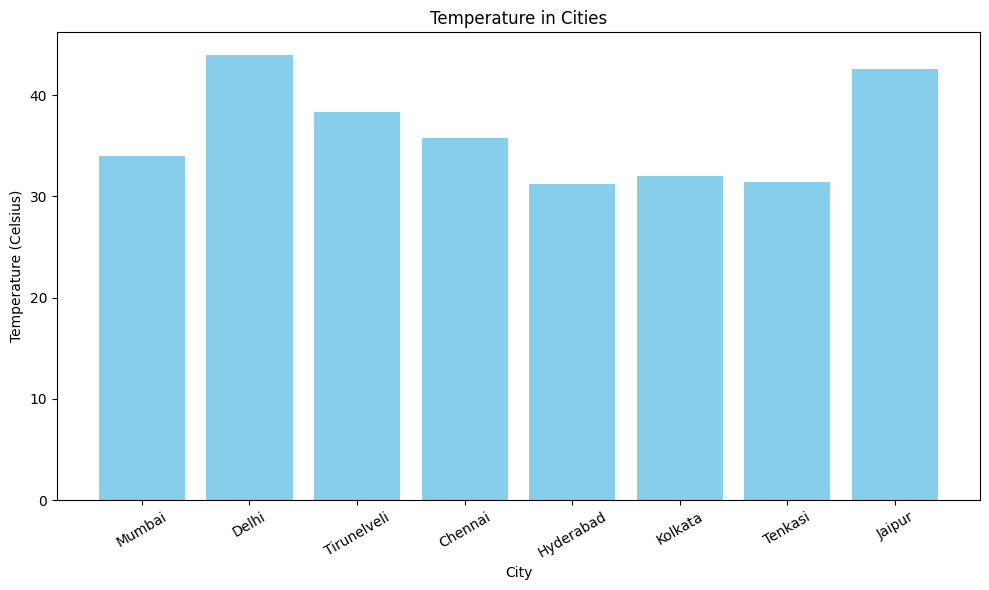

In [19]:
import requests

plt.figure(figsize=(10,6))
plt.bar(weather_df['city'], weather_df['temperature'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (Celsius)')
plt.title('Temperature in Cities')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()